In [1]:
from rabtracks import *
sns.set_context("paper")

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered

IRENE 1981.0
FLOYD 1993.0
IRIS 1995.0
KARL 1998.0
GORDON 2006.0
HENRI 2015.0
PABLO 2019.0


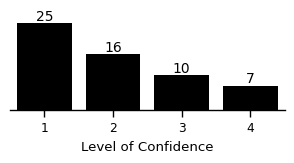

In [2]:
eib = xr.open_dataset("../RABTracks/RABTracks_NA.nc")
eib = clean(eib.sel(source = [
# 'SyCLoPS-ERA5',
# 'SyCLoPS-JRA3Q',
# 'SyCLoPS-MERRA2',
 'TRACK-ERA5',
 'TRACK-JRA3Q',
 'TRACK-MERRA2',
 'TRACK-NCEP', 
]).where(
    (eib.time.dt.year >= 1980) & (eib.time.dt.year <= 2022) &
    (eib.lon >= -15) & (eib.lon <= 20) & 
    (eib.lat >= 30) & (eib.lat <= 60)
))

CTO_FR = pd.DataFrame()
for s in [
# 'SyCLoPS-ERA5',
# 'SyCLoPS-JRA3Q',
# 'SyCLoPS-MERRA2',
 'TRACK-ERA5',
 'TRACK-JRA3Q',
 'TRACK-MERRA2',
 'TRACK-NCEP', ]:
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(eib_s.track_id.notnull()))
    eib_s = eib_s.hrcn.interp_time("1h")
    eib_s = eib_s.hrcn.add_country()
    CTO_FR = pd.concat([CTO_FR, (eib_s.country == "France").groupby(eib_s.track_id).max().to_dataframe().reset_index()])
C = CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum(axis = 1)
CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum()

sns.set_context("paper")

fig = plt.figure(figsize = cm2inch([9,3]))
X = np.arange(1,5)
Y = []
for n in X:
    Y.append((C >= n).sum())
ax = sns.barplot(x=X, y=Y, estimator="sum", errorbar=None, color = "k")
ax.bar_label(ax.containers[0], fontsize=10);
sns.despine(left = True)
ax.yaxis.set_visible(False)
ax.set_xlabel("Level of Confidence")
#ax.set_title("Number of CTO reaching France\nover 1980-2022")

plt.savefig("conf_level_CTO_in_France.png", bbox_inches = "tight")
plt.savefig("conf_level_CTO_in_France.pdf", bbox_inches = "tight")

N, Y = [], []
for tid in C[C == 4].index.values:
    N.append(clean(eib.where(eib.track_id == tid)).name.max().values)
    Y.append(eib.where(eib.track_id == tid).time.dt.year.mean().values)
    print(clean(eib.where(eib.track_id == tid)).name.max().values, 
          clean(eib.where(eib.track_id == tid)).time.dt.year.mean().values)

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered

IVAN 1998.0
JEANNE 1998.0
VINCE 2005.0
GORDON 2012.0
RAFAEL 2012.0
UNNAMED 2017.0
LESLIE 2018.0
MICHAEL 2018.0
ALPHA 2020.0


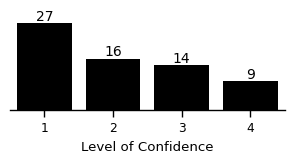

In [3]:
# Spain
CTO_FR = pd.DataFrame()
for s in [
 'TRACK-ERA5',
 'TRACK-JRA3Q',
 'TRACK-MERRA2',
 'TRACK-NCEP', ]:
    eib_s = eib.sel(source = s)
    eib_s = clean(eib_s.where(eib_s.track_id.notnull()))
    eib_s = eib_s.hrcn.interp_time("1h")
    eib_s = eib_s.hrcn.add_country()
    CTO_FR = pd.concat([CTO_FR, (eib_s.country == "Spain").groupby(eib_s.track_id).max().to_dataframe().reset_index()])
C = CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum(axis = 1)
CTO_FR.pivot_table(index = "track_id", columns = "source", values = "country").fillna(0).sum()

sns.set_context("paper")

fig = plt.figure(figsize = cm2inch([9,3]))
X = np.arange(1,5)
Y = []
for n in X:
    Y.append((C >= n).sum())
ax = sns.barplot(x=X, y=Y, estimator="sum", errorbar=None, color = "k")
ax.bar_label(ax.containers[0], fontsize=10);
sns.despine(left = True)
ax.yaxis.set_visible(False)
ax.set_xlabel("Level of Confidence")

N, Y, ID = [], [], []
for tid in C[C == 4].index.values:
    N.append(clean(eib.where(eib.track_id == tid)).name.max().values)
    Y.append(eib.where(eib.track_id == tid).time.dt.year.mean().values)
    ID.append(tid)
    print(clean(eib.where(eib.track_id == tid)).name.max().values, 
          clean(eib.where(eib.track_id == tid)).time.dt.year.mean().values)

In [4]:
[int(y) for y in Y]

[1998, 1998, 2005, 2012, 2012, 2017, 2018, 2018, 2020]

In [5]:
ID

['1998262N13333',
 '1998264N10343',
 '2005281N33339',
 '2012229N28305',
 '2012287N15297',
 '2017240N31279',
 '2018265N35315',
 '2018280N18273',
 '2020259N47338']

/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/users/sbourdin/.conda/envs/huracanpy/lib/python3.13/site-packages/huracanpy/plot/_tracks.py:53: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/home/user

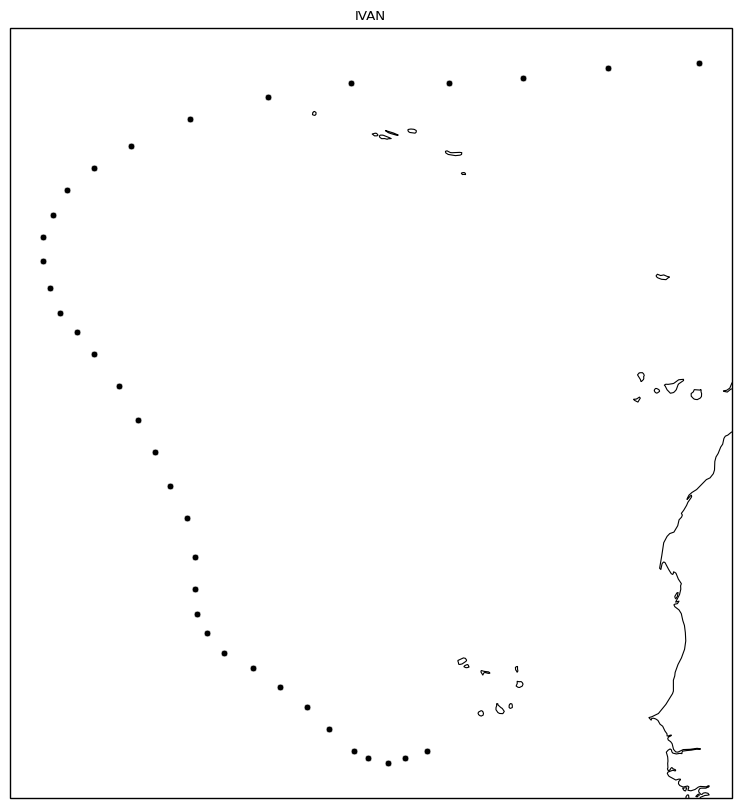

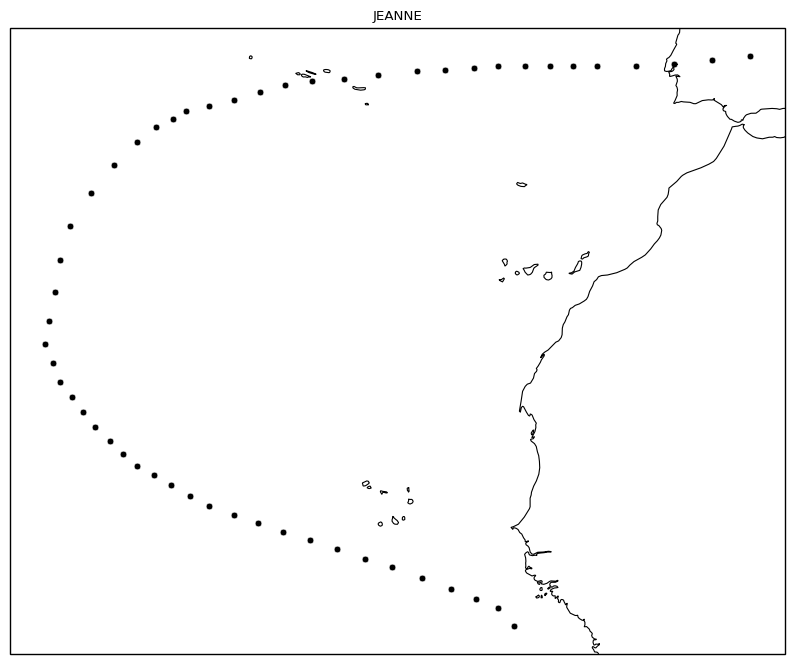

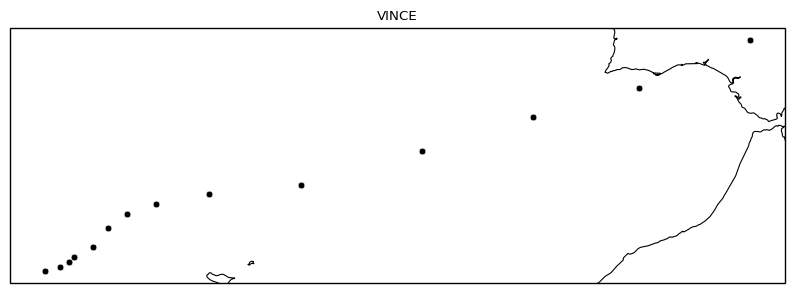

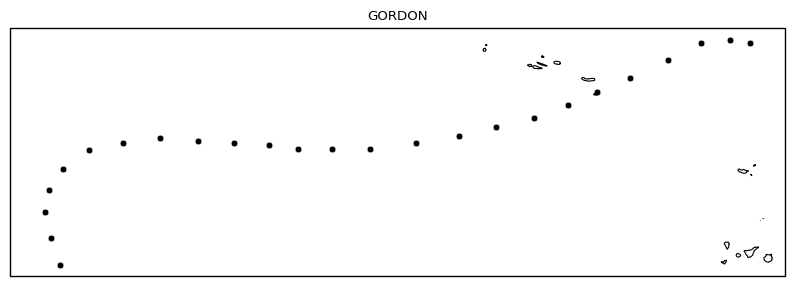

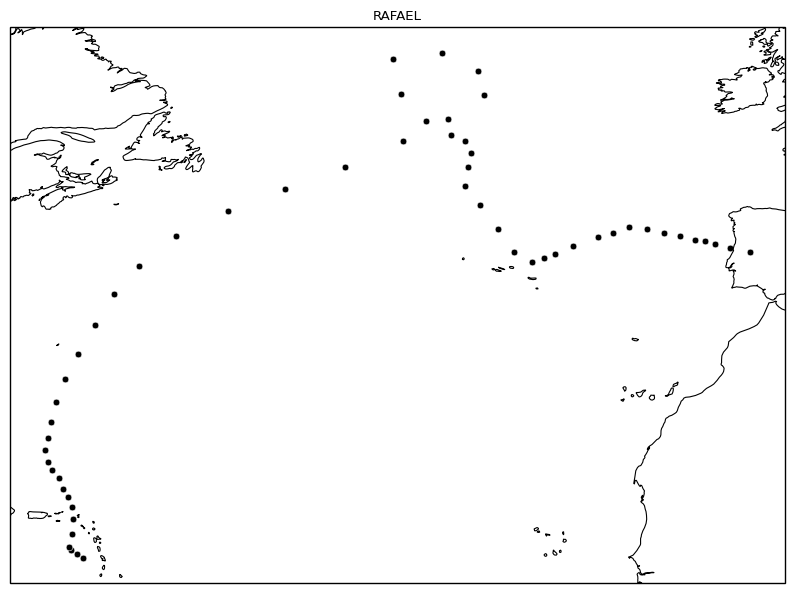

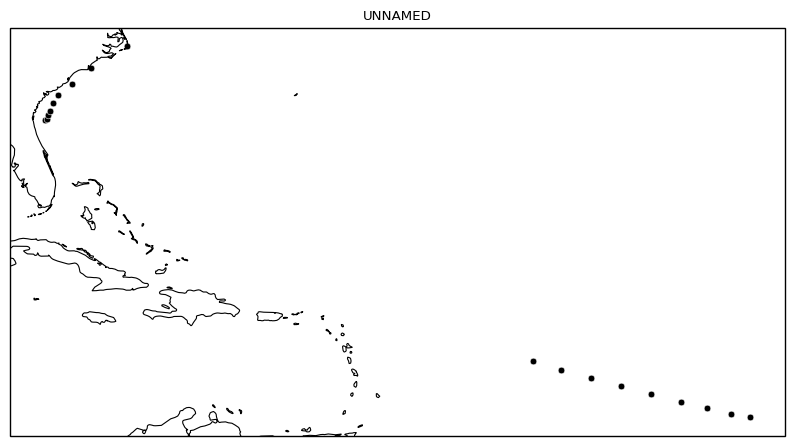

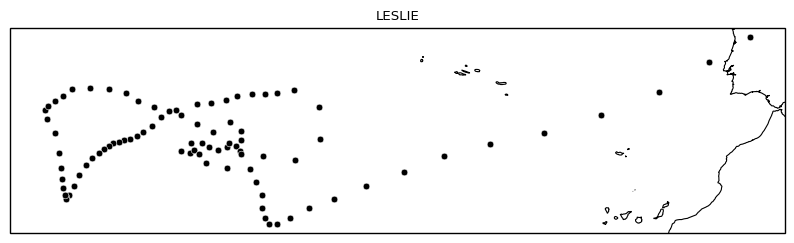

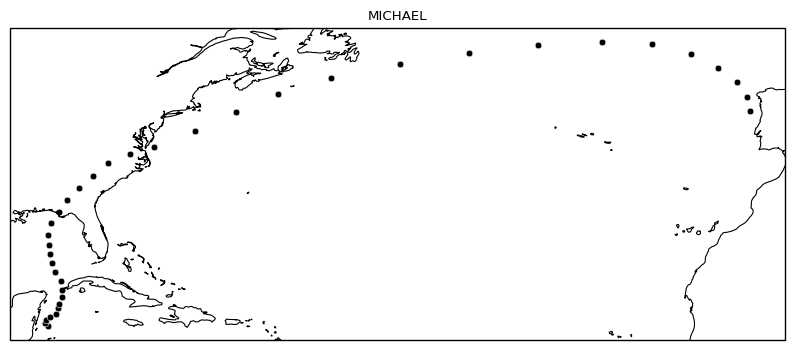

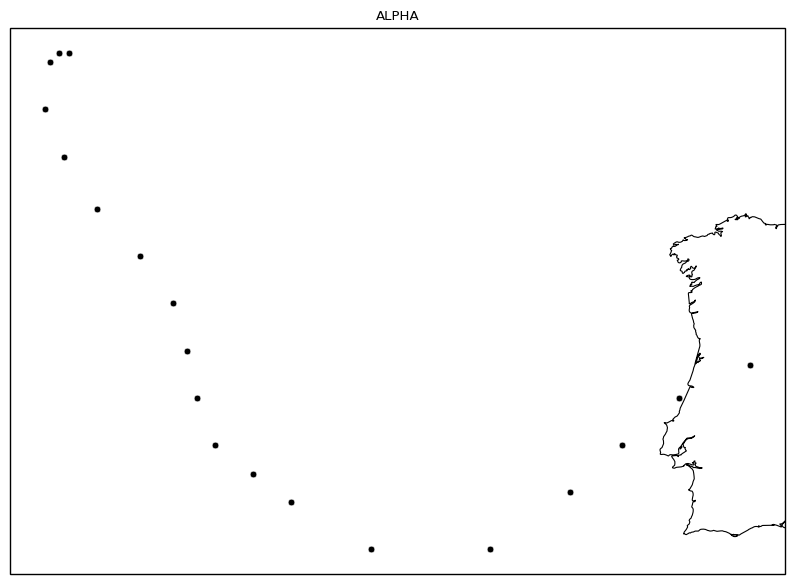

In [6]:
eib = xr.open_dataset("../RABTracks/RABTracks_NA.nc")
for n, y in zip(N, Y):
    eib.where((eib.name == n) & (eib.time.dt.year == int(y))).sel(source = "IBTrACS").hrcn.plot_tracks()
    plt.title(n)

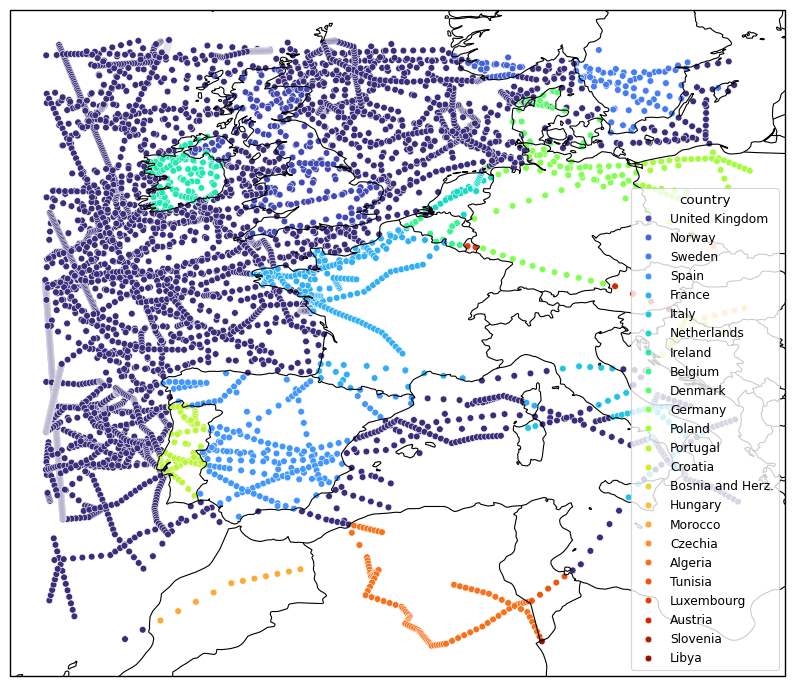

In [7]:
import cartopy.feature as cfeature
fig, ax = eib_s.hrcn.plot_tracks(subplot_kws = dict(projection = ccrs.PlateCarree()), intensity_var_name = "country")
ax.add_feature(cfeature.BORDERS.with_scale('50m'))

<Axes: xlabel='lon', ylabel='lat'>

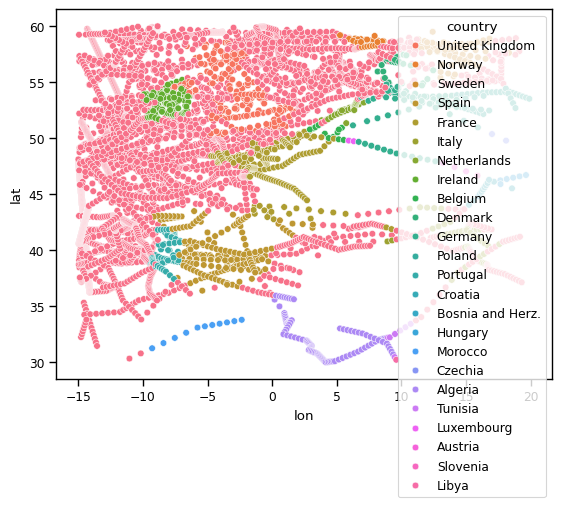

In [8]:
sns.scatterplot(data = eib_s, x = "lon", y = "lat", hue = "country")

In [9]:
eib.sel(source = "TRACK-NCEP")[["lon", "lat", "track_id"]].hrcn.interp_time("1h")

ValueError: These variables cannot be found in this dataset: ['time']

In [ ]:
from dask.diagnostics import ProgressBar

# Chunk your dataset along the looped dimension
ds_chunked = eib.chunk({"record": 10})

result = xr.apply_ufunc(
    huracanpy.info.country,
    ds_chunked["lon"],
    ds_chunked["lat"],
    input_core_dims=[["source"], ["source"]],
    output_core_dims=[["source"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[object],
)

# Compute with a progress bar
with ProgressBar():
    result = result.compute()

In [ ]:
eib["country"]=  result.copy()

In [ ]:
eib_df = eib.to_dataframe()

In [ ]:
eib_df[eib_df.country == "France"]

In [ ]:
eib_FR = clean(eib.where(eib.country == "France"))

In [ ]:
from dask.diagnostics import ProgressBar

# Chunk your dataset along the looped dimension
ds_chunked = eib_FR.chunk({"record": 10})

result = xr.apply_ufunc(
    huracanpy.info.continent,
    ds_chunked["lon"],
    ds_chunked["lat"],
    input_core_dims=[["source"], ["source"]],
    output_core_dims=[["source"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[object],
)

# Compute with a progress bar
with ProgressBar():
    result = result.compute()

In [ ]:
eib_FR["continent"] = result.copy()

In [ ]:
eib_FR.where(eib_FR.continent == "Europe", drop = True)

In [ ]:
eib_FR